# **PHASE 1:SECURITY TELEMETRY ASSESSMENT GUIDE DATASET**

DATASET OVERVIEW
Shape: (9516837, 45)

Columns:
['Id', 'OrgId', 'IncidentId', 'AlertId', 'Timestamp', 'DetectorId', 'AlertTitle', 'Category', 'MitreTechniques', 'IncidentGrade', 'ActionGrouped', 'ActionGranular', 'EntityType', 'EvidenceRole', 'DeviceId', 'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn', 'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId', 'EmailClusterId', 'RegistryKey', 'RegistryValueName', 'RegistryValueData', 'ApplicationId', 'ApplicationName', 'OAuthApplicationId', 'ThreatFamily', 'FileName', 'FolderPath', 'ResourceIdName', 'ResourceType', 'Roles', 'OSFamily', 'OSVersion', 'AntispamDirection', 'SuspicionLevel', 'LastVerdict', 'CountryCode', 'State', 'City']

Data Types:
Id                      int64
OrgId                   int64
IncidentId              int64
AlertId                 int64
Timestamp              object
DetectorId              int64
AlertTitle              int64
Category               object
MitreTechniques        object
Inciden

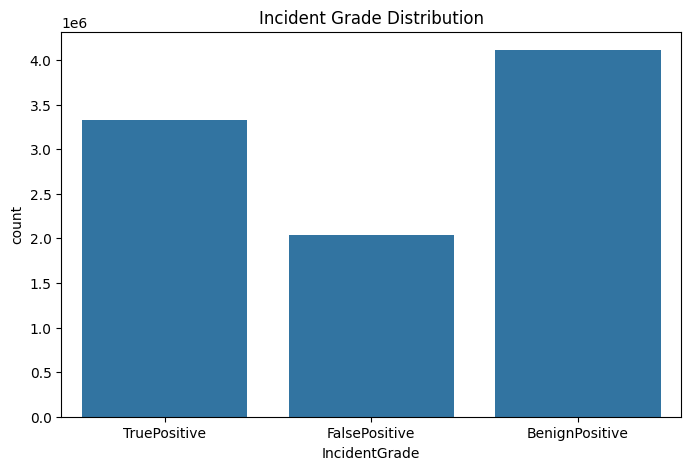

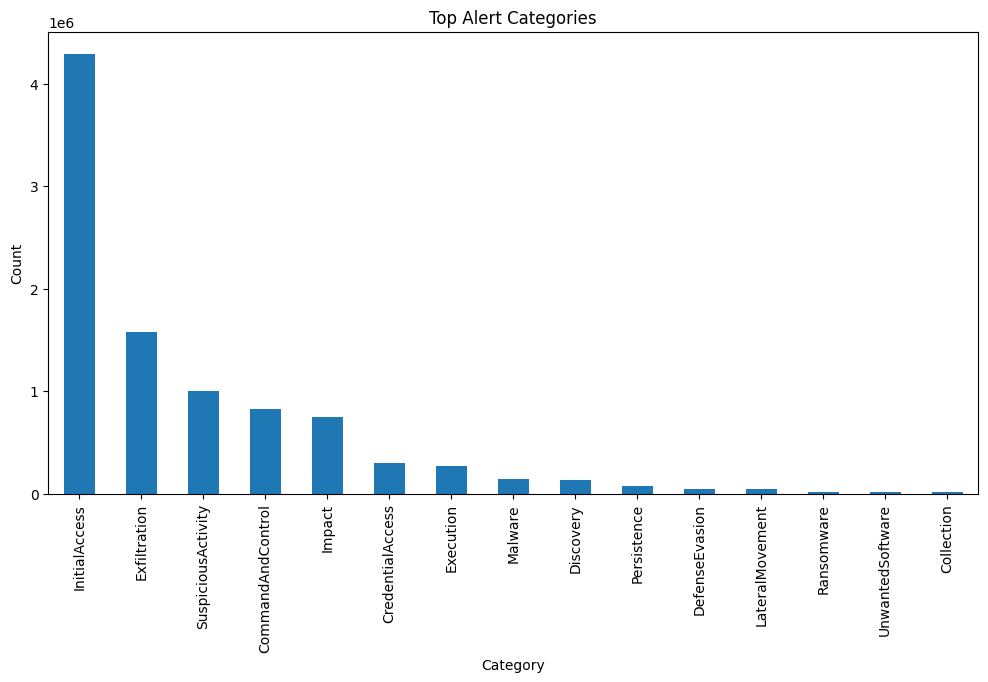

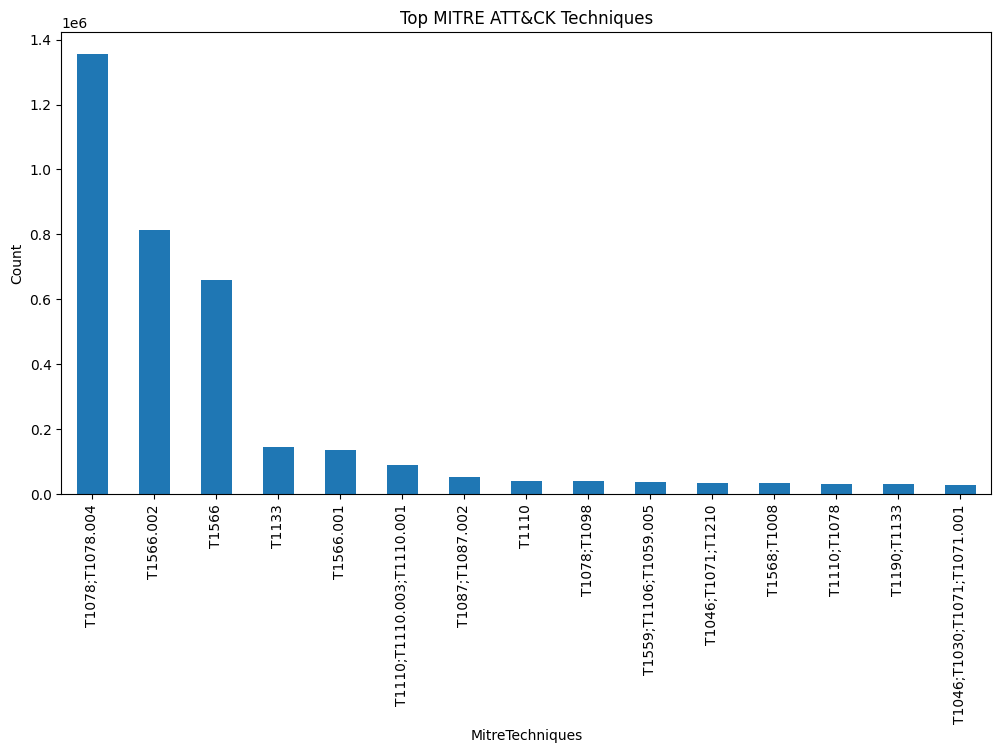

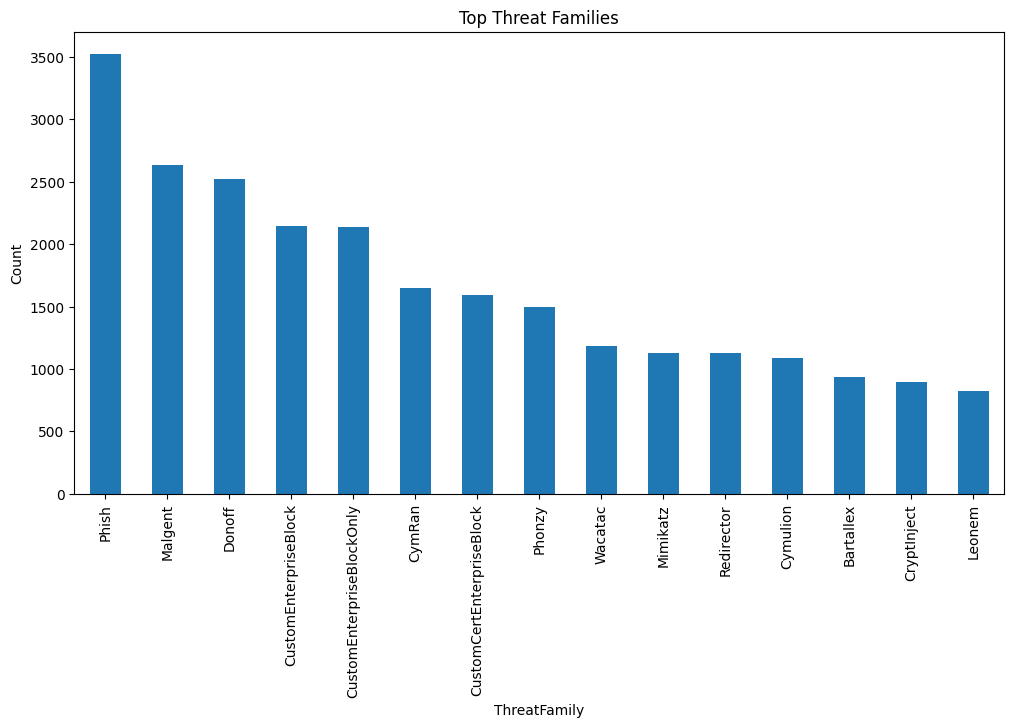

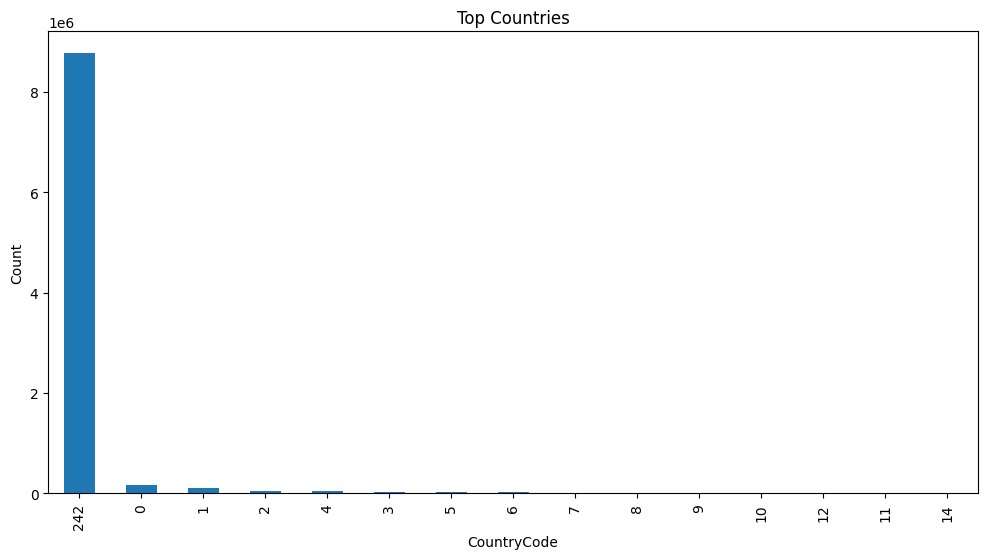

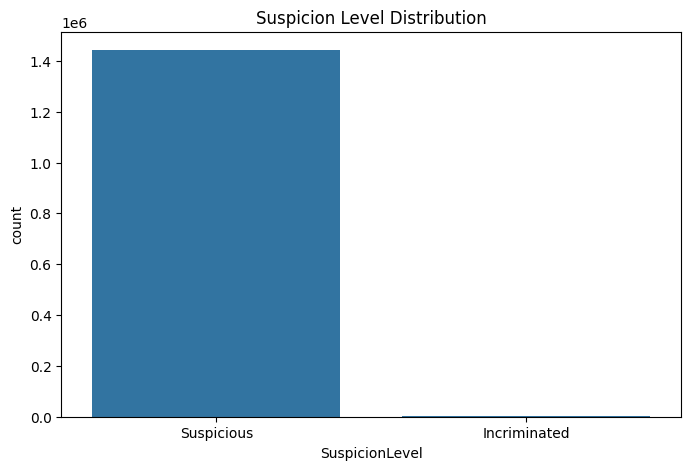


Dataset Summary
                  Id         OrgId    IncidentId       AlertId  \
count   9.516837e+06  9.516837e+06  9.516837e+06  9.516837e+06   
unique           NaN           NaN           NaN           NaN   
top              NaN           NaN           NaN           NaN   
freq             NaN           NaN           NaN           NaN   
mean    8.425494e+11  1.815800e+02  7.066349e+04  4.065188e+05   
std     4.962499e+11  3.867784e+02  1.208369e+05  4.592827e+05   
min     0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%     4.123169e+11  1.000000e+01  5.040000e+02  2.324200e+04   
50%     8.418136e+11  4.500000e+01  1.033600e+04  2.166520e+05   
75%     1.271310e+12  1.710000e+02  8.432900e+04  6.715770e+05   
max     1.709397e+12  6.147000e+03  5.997060e+05  1.721456e+06   

                       Timestamp    DetectorId    AlertTitle       Category  \
count                    9516837  9.516837e+06  9.516837e+06        9516837   
unique                    760944

In [1]:
# ==========================================================
# PHASE 1
# SECURITY TELEMETRY ASSESSMENT
# GUIDE DATASET
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("C:\\Users\\Administrator\\OneDrive\\Documents\\3rd sem\\project Lab\\GUIDE Dataset\\GUIDE_Train.csv")

print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# ==========================================================
# BASIC INFORMATION
# ==========================================================

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

# ==========================================================
# INCIDENT GRADE DISTRIBUTION
# ==========================================================

print("\nIncident Grade Distribution")

print(df["IncidentGrade"].value_counts())

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="IncidentGrade"
)

plt.title("Incident Grade Distribution")

plt.show()

# ==========================================================
# ALERT CATEGORY DISTRIBUTION
# ==========================================================

plt.figure(figsize=(12,6))

df["Category"].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Top Alert Categories")

plt.ylabel("Count")

plt.show()

# ==========================================================
# MITRE TECHNIQUES
# ==========================================================

plt.figure(figsize=(12,6))

df["MitreTechniques"].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Top MITRE ATT&CK Techniques")

plt.ylabel("Count")

plt.show()

# ==========================================================
# THREAT FAMILY ANALYSIS
# ==========================================================

plt.figure(figsize=(12,6))

df["ThreatFamily"].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Top Threat Families")

plt.ylabel("Count")

plt.show()

# ==========================================================
# COUNTRY DISTRIBUTION
# ==========================================================

plt.figure(figsize=(12,6))

df["CountryCode"].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Top Countries")

plt.ylabel("Count")

plt.show()

# ==========================================================
# SUSPICION LEVEL DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="SuspicionLevel"
)

plt.title("Suspicion Level Distribution")

plt.show()

# ==========================================================
# SUMMARY REPORT
# ==========================================================

print("\nDataset Summary")

print(df.describe(include="all"))

print("\nEDA Completed Successfully")

# **Phase 2: EDA and Data Preparation**

In [2]:
# ==========================================================
# PHASE 2
# DETECTION FEATURE ENGINEERING
# GUIDE DATASET
# ==========================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("C:\\Users\\Administrator\\OneDrive\\Documents\\3rd sem\\project Lab\\GUIDE Dataset\\guide_filtered_dataset.csv")

print("Original Shape:", df.shape)

# ==========================================================
# FEATURE SELECTION
# ==========================================================

selected_columns = [
    'Timestamp',
    'AlertTitle',
    'Category',
    'MitreTechniques',
    'EntityType',
    'EvidenceRole',
    'DeviceName',
    'OSFamily',
    'OSVersion',
    'IpAddress',
    'AccountName',
    'ThreatFamily',
    'SuspicionLevel',
    'LastVerdict',
    'CountryCode',
    'IncidentGrade'
]

df = df[selected_columns]

print("Filtered Shape:", df.shape)

# ==========================================================
# MISSING VALUE HANDLING
# ==========================================================

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(0)

# ==========================================================
# REMOVE DUPLICATES
# ==========================================================

before = df.shape[0]

df = df.drop_duplicates()

after = df.shape[0]

print("Duplicates Removed:", before - after)

# ==========================================================
# TIMESTAMP FEATURE ENGINEERING
# ==========================================================

df['Timestamp'] = pd.to_datetime(
    df['Timestamp'],
    errors='coerce'
)

df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['Month'] = df['Timestamp'].dt.month

df.drop("Timestamp", axis=1, inplace=True)

# ==========================================================
# REMOVE HIGH-CARDINALITY FIELDS
# ==========================================================

drop_columns = [
    'DeviceName',
    'IpAddress',
    'AccountName'
]

df.drop(columns=drop_columns, inplace=True)

# ==========================================================
# ENCODE TARGET VARIABLE
# ==========================================================

target_encoder = LabelEncoder()

df['IncidentGrade'] = target_encoder.fit_transform(
    df['IncidentGrade']
)

print("\nTarget Mapping:")

for cls, val in zip(
    target_encoder.classes_,
    target_encoder.transform(target_encoder.classes_)
):
    print(f"{cls} --> {val}")

# ==========================================================
# ENCODE CATEGORICAL FEATURES
# ==========================================================

categorical_columns = df.select_dtypes(
    include='object'
).columns

encoders = {}

for col in categorical_columns:

    encoder = LabelEncoder()

    df[col] = encoder.fit_transform(
        df[col].astype(str)
    )

    encoders[col] = encoder

print("\nCategorical Encoding Complete")

# ==========================================================
# DATA VALIDATION
# ==========================================================

print("\nFinal Shape:", df.shape)

print("\nMissing Values:")

print(df.isnull().sum())

print("\nData Types:")

print(df.dtypes)

# ==========================================================
# FEATURES & TARGET
# ==========================================================

X = df.drop("IncidentGrade", axis=1)

y = df["IncidentGrade"]

print("\nFeature Shape:", X.shape)

print("Target Shape:", y.shape)

# ==========================================================
# SAVE PREPROCESSED DATASET
# ==========================================================

df.to_csv(
    "GUIDE_Preprocessed.csv",
    index=False
)

print("\nGUIDE_Preprocessed.csv saved successfully")

# ==========================================================
# PHASE 2 COMPLETE
# ==========================================================

Original Shape: (998, 18)
Filtered Shape: (998, 16)
Duplicates Removed: 0

Target Mapping:
BenignPositive --> 0
FalsePositive --> 1
TruePositive --> 2

Categorical Encoding Complete

Final Shape: (998, 15)

Missing Values:
AlertTitle         0
Category           0
MitreTechniques    0
EntityType         0
EvidenceRole       0
OSFamily           0
OSVersion          0
ThreatFamily       0
SuspicionLevel     0
LastVerdict        0
CountryCode        0
IncidentGrade      0
Hour               0
DayOfWeek          0
Month              0
dtype: int64

Data Types:
AlertTitle         int64
Category           int64
MitreTechniques    int64
EntityType         int64
EvidenceRole       int64
OSFamily           int64
OSVersion          int64
ThreatFamily       int64
SuspicionLevel     int64
LastVerdict        int64
CountryCode        int64
IncidentGrade      int64
Hour               int32
DayOfWeek          int32
Month              int32
dtype: object

Feature Shape: (998, 14)
Target Shape: (998,)


# **PHASE 3:BASELINE DETECTION ENGINE RANDOM FOREST ALERT TRIAGE MODEL**

Dataset Shape: (43147, 15)
Feature Shape: (43147, 14)
Target Shape: (43147,)

Training Data: (34517, 14)
Testing Data: (8630, 14)

Training Random Forest Model...
Training Completed

DETECTION PERFORMANCE
Accuracy : 0.6971

Classification Report
              precision    recall  f1-score   support

           0       0.70      0.77      0.73      3457
           1       0.65      0.55      0.60      2048
           2       0.72      0.72      0.72      3125

    accuracy                           0.70      8630
   macro avg       0.69      0.68      0.68      8630
weighted avg       0.70      0.70      0.69      8630



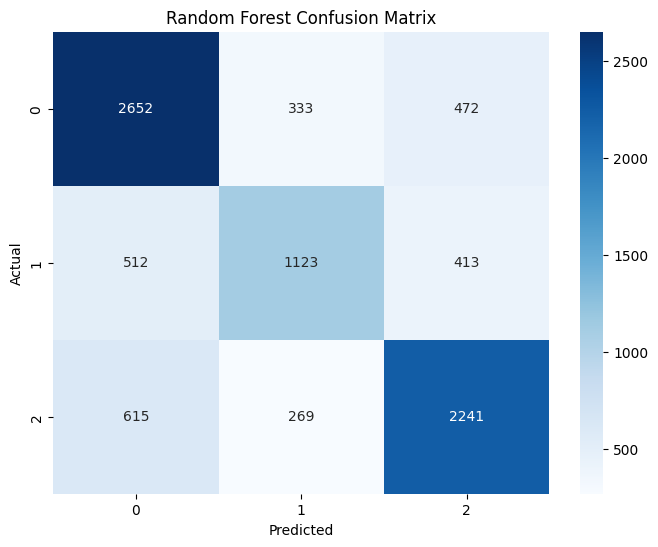


TOP DETECTION SIGNALS
            Feature  Importance
0        AlertTitle    0.317016
11             Hour    0.256828
12        DayOfWeek    0.114060
2   MitreTechniques    0.069453
1          Category    0.064863
3        EntityType    0.055922
10      CountryCode    0.055621
9       LastVerdict    0.024933
13            Month    0.014879
8    SuspicionLevel    0.011139
4      EvidenceRole    0.010859
7      ThreatFamily    0.001945
5          OSFamily    0.001391
6         OSVersion    0.001089


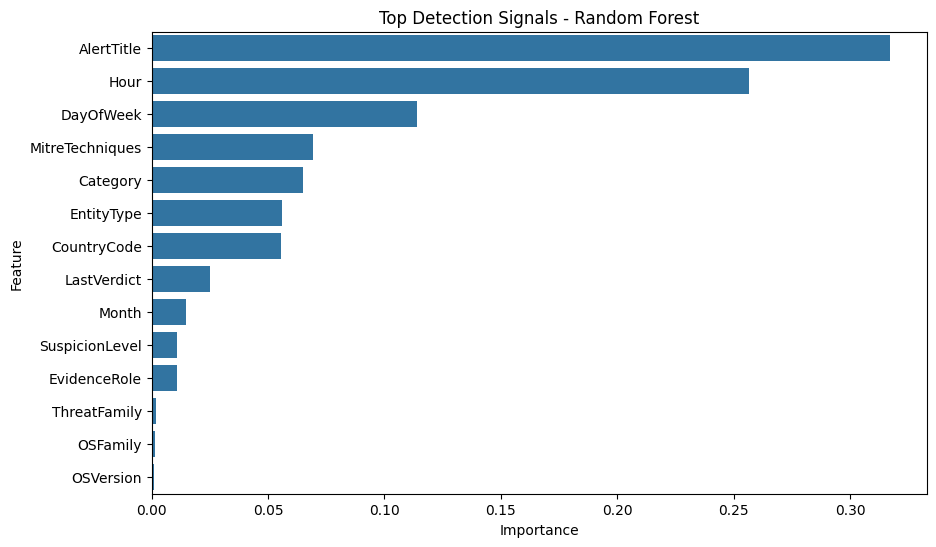


Model Saved Successfully
Feature Importance Saved


In [1]:
# ==========================================================
# PHASE 3
# BASELINE DETECTION ENGINE
# RANDOM FOREST ALERT TRIAGE MODEL
# ==========================================================

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# LOAD PREPROCESSED DATASET
# ==========================================================

df = pd.read_csv("C:\\Users\\Administrator\\OneDrive\\Documents\\3rd sem\\project Lab\\GUIDE Dataset\\GUIDE_Preprocessed.csv")

print("Dataset Shape:", df.shape)

# ==========================================================
# FEATURES & TARGET
# ==========================================================

X = df.drop("IncidentGrade", axis=1)
y = df["IncidentGrade"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# ==========================================================
# RANDOM FOREST MODEL
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest Model...")

rf_model.fit(X_train, y_train)

print("Training Completed")

# ==========================================================
# PREDICTIONS
# ==========================================================

y_pred = rf_model.predict(X_test)

# ==========================================================
# PERFORMANCE EVALUATION
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n===================================")
print("DETECTION PERFORMANCE")
print("===================================")

print(f"Accuracy : {accuracy:.4f}")

print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n===================================")
print("TOP DETECTION SIGNALS")
print("===================================")

print(feature_importance)

# ==========================================================
# FEATURE IMPORTANCE VISUALIZATION
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top Detection Signals - Random Forest")

plt.show()

# ==========================================================
# SAVE MODEL
# ==========================================================

joblib.dump(
    rf_model,
    "Threat_Detection_RF.pkl"
)

print("\nModel Saved Successfully")

# ==========================================================
# SAVE FEATURE IMPORTANCE
# ==========================================================

feature_importance.to_csv(
    "RF_Feature_Importance.csv",
    index=False
)

print("Feature Importance Saved")

# ==========================================================
# PHASE 3 COMPLETE
# ==========================================================

# **PHASE 4:ADVANCED DETECTION ENGINE XGBOOST ALERT TRIAGE MODEL**


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset Shape: (43147, 15)
Feature Shape: (43147, 14)
Target Shape: (43147,)

Training Data: (34517, 14)
Testing Data: (8630, 14)

Training XGBoost Model...
Training Completed

XGBOOST DETECTION PERFORMANCE
Accuracy : 0.7329

Classification Report
              precision    recall  f1-score   support

           0       0.68      0.89      0.77      3457
           1       0.78      0.51      0.61      2048
           2       0.80      0.71      0.75      3125

    accuracy                           0.73      8630
   macro avg       0.75      0.70      0.71      8630
weighted avg       0.75      0.73      0.73      8630



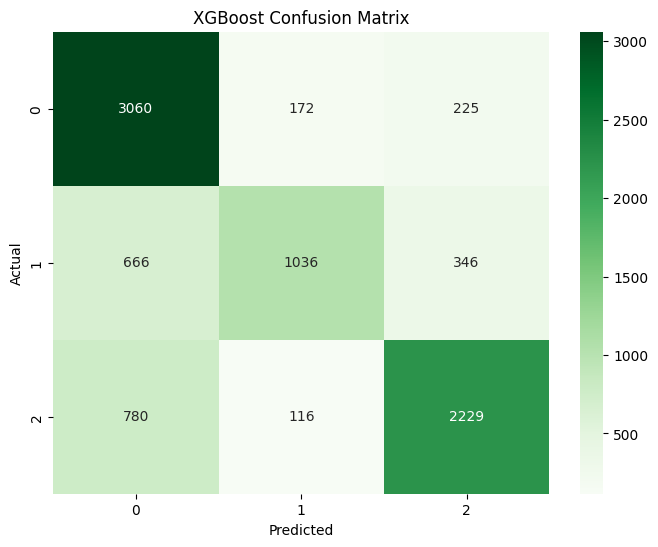


TOP DETECTION SIGNALS
            Feature  Importance
9       LastVerdict    0.168434
0        AlertTitle    0.155424
13            Month    0.114296
2   MitreTechniques    0.101420
10      CountryCode    0.096194
1          Category    0.094913
8    SuspicionLevel    0.058179
3        EntityType    0.043578
4      EvidenceRole    0.036403
12        DayOfWeek    0.030192
5          OSFamily    0.027279
11             Hour    0.026042
6         OSVersion    0.024635
7      ThreatFamily    0.023011


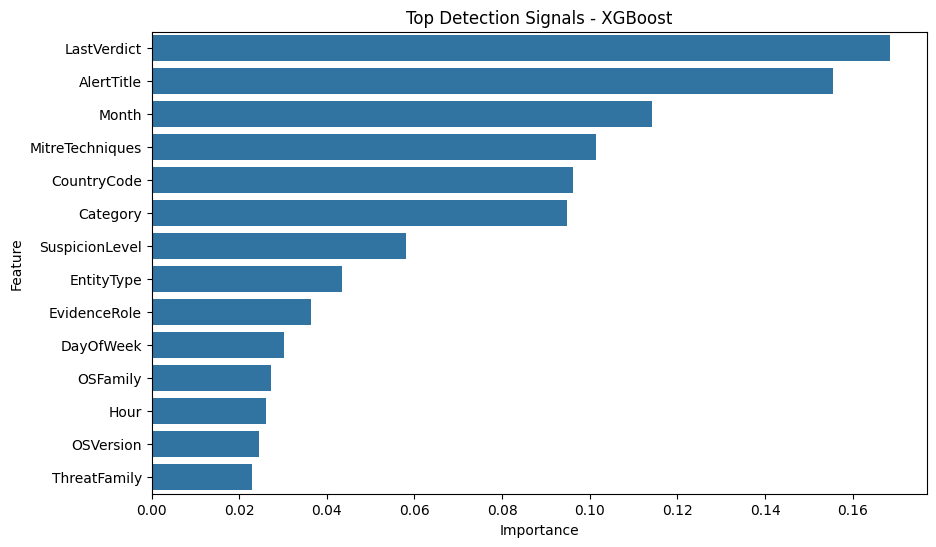


Model Saved Successfully
Feature Importance Saved

PHASE 4 COMPLETE

Artifacts Generated:

1. Threat_Detection_XGBoost.pkl
2. XGBoost_Feature_Importance.csv
3. Classification Report
4. Confusion Matrix
5. Feature Importance Chart

Next Phase:
PHASE 5 - Detection Explainability (SHAP)



In [5]:
# ==========================================================
# PHASE 4
# ADVANCED DETECTION ENGINE
# XGBOOST ALERT TRIAGE MODEL
# ==========================================================

!pip install xgboost -q

import pandas as pd
import joblib

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# LOAD PREPROCESSED DATASET
# ==========================================================

df = pd.read_csv("C:\\Users\\Administrator\\OneDrive\\Documents\\3rd sem\\project Lab\\GUIDE Dataset\\GUIDE_Preprocessed.csv")

print("Dataset Shape:", df.shape)

# ==========================================================
# FEATURES & TARGET
# ==========================================================

X = df.drop("IncidentGrade", axis=1)
y = df["IncidentGrade"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# ==========================================================
# XGBOOST DETECTION ENGINE
# ==========================================================

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

print("\nTraining XGBoost Model...")

xgb_model.fit(
    X_train,
    y_train
)

print("Training Completed")

# ==========================================================
# PREDICTIONS
# ==========================================================

y_pred = xgb_model.predict(X_test)

# ==========================================================
# PERFORMANCE EVALUATION
# ==========================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n===================================")
print("XGBOOST DETECTION PERFORMANCE")
print("===================================")

print(f"Accuracy : {accuracy:.4f}")

print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\n===================================")
print("TOP DETECTION SIGNALS")
print("===================================")

print(feature_importance)

# ==========================================================
# FEATURE IMPORTANCE VISUALIZATION
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top Detection Signals - XGBoost")

plt.show()

# ==========================================================
# SAVE MODEL
# ==========================================================

joblib.dump(
    xgb_model,
    "Threat_Detection_XGBoost.pkl"
)

print("\nModel Saved Successfully")

# ==========================================================
# SAVE FEATURE IMPORTANCE
# ==========================================================

feature_importance.to_csv(
    "XGBoost_Feature_Importance.csv",
    index=False
)

print("Feature Importance Saved")

# ==========================================================
# MODEL COMPARISON SUMMARY
# ==========================================================

print("\n===================================")
print("PHASE 4 COMPLETE")
print("===================================")

print("""
Artifacts Generated:

1. Threat_Detection_XGBoost.pkl
2. XGBoost_Feature_Importance.csv
3. Classification Report
4. Confusion Matrix
5. Feature Importance Chart

Next Phase:
PHASE 5 - Detection Explainability (SHAP)
""")

# **PHASE 5: DETECTION EXPLAINABILITY (SHAP) AI-POWERED SECURITY OPERATIONS PLATFORM**


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset Shape: (43147, 15)
Feature Shape: (43147, 14)
Target Shape: (43147,)

XGBoost Detection Engine Loaded Successfully

Generating SHAP Values...
SHAP Analysis Completed
SHAP Shape: (43147, 14, 3)

Generating Global Feature Importance...


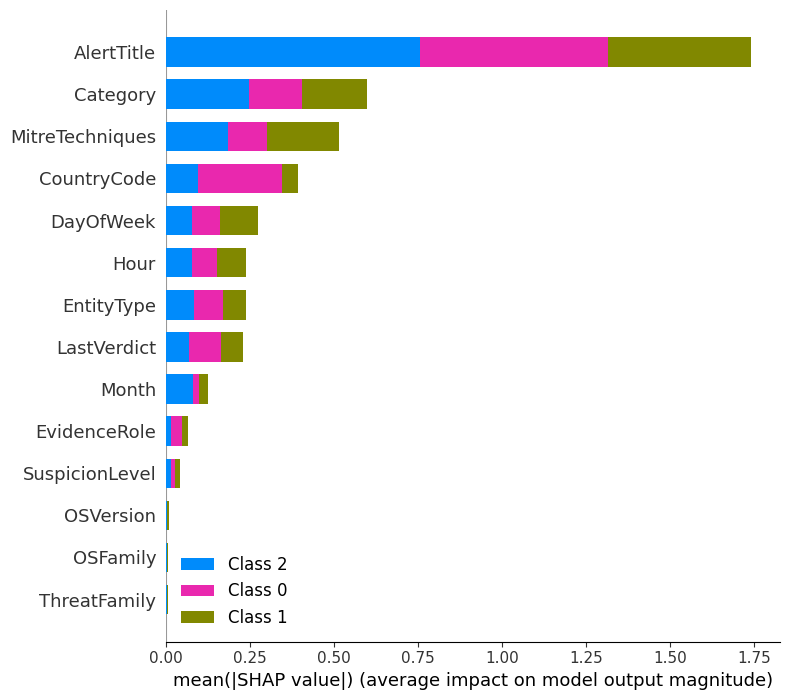


Generating SHAP Summary Plot...


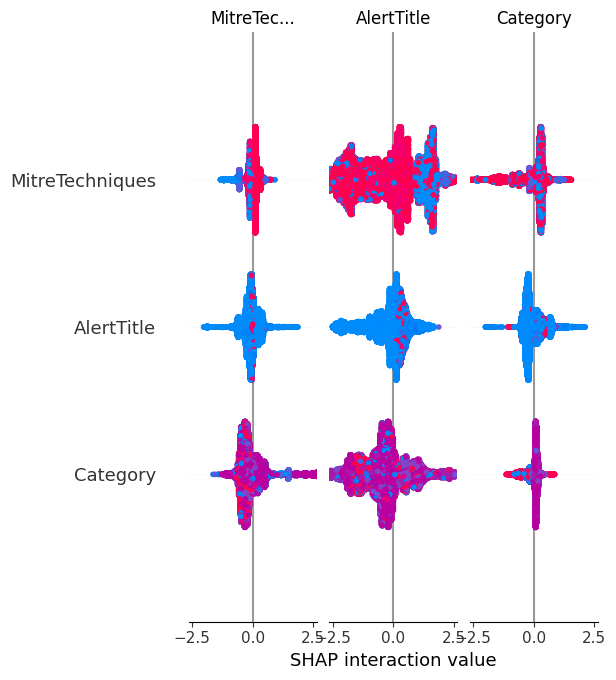


Generating Detection Signal Rankings...

TOP DETECTION SIGNALS
            Feature  Mean_SHAP_Impact
0        AlertTitle          0.580263
1          Category          0.199162
2   MitreTechniques          0.171719
10      CountryCode          0.130940
12        DayOfWeek          0.091122
11             Hour          0.079453
3        EntityType          0.079355
9       LastVerdict          0.076577
13            Month          0.041999
4      EvidenceRole          0.021975
8    SuspicionLevel          0.013847
6         OSVersion          0.003210
5          OSFamily          0.002580
7      ThreatFamily          0.002327

SHAP Feature Importance Saved


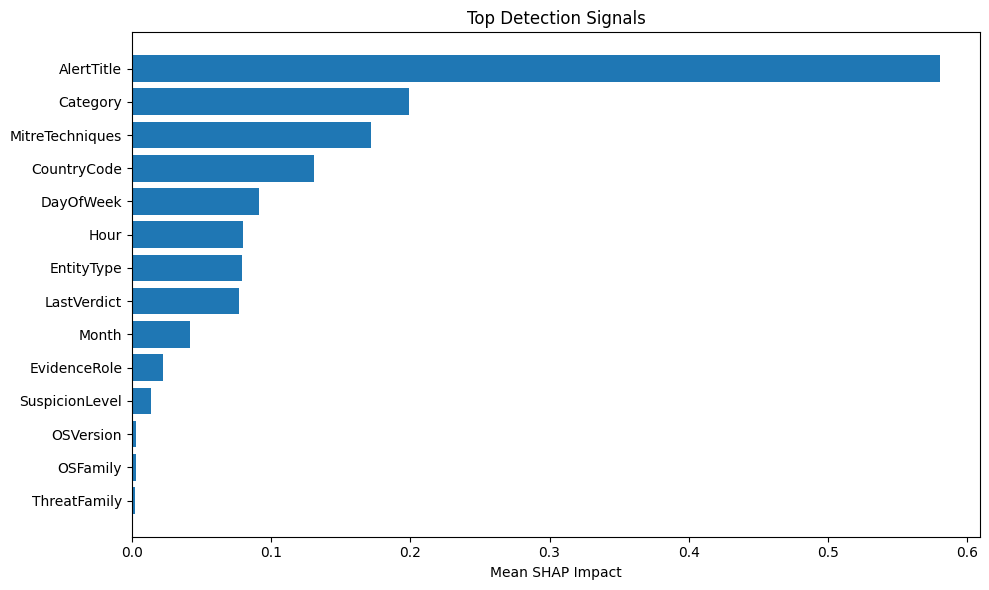


Explaining Incident #10


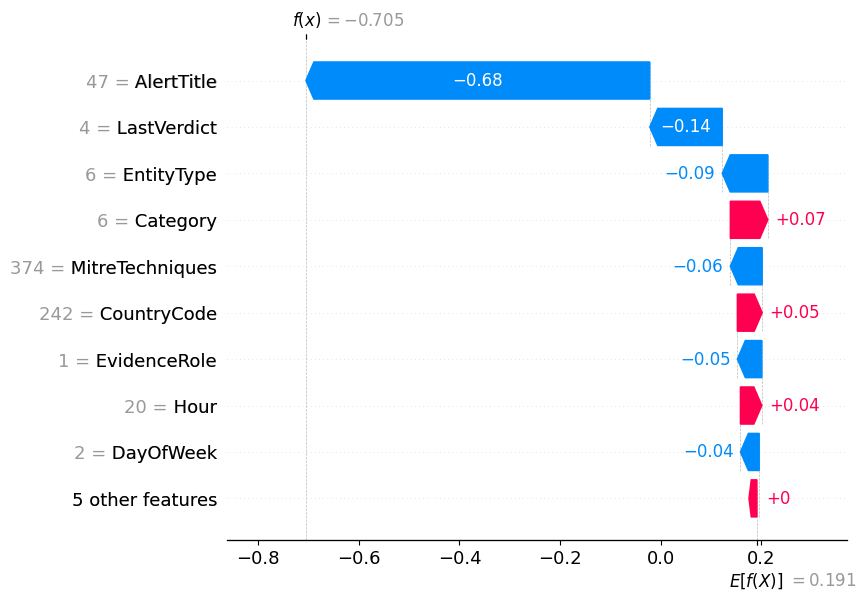


Generating Dependence Plot for: AlertTitle


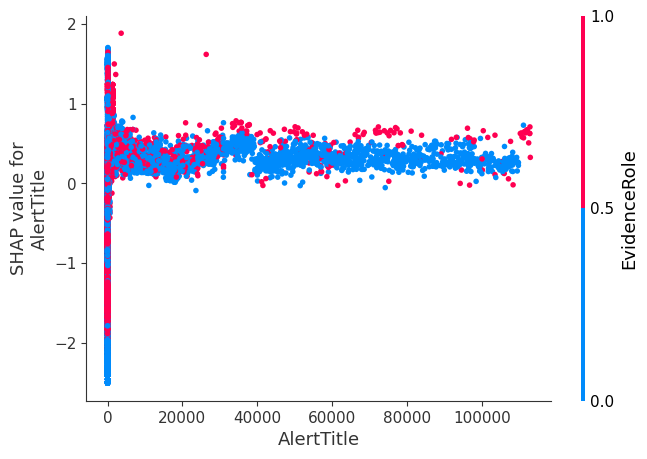


DETECTION EXPLAINABILITY COMPLETED

Artifacts Generated:

1. SHAP Summary Plot
2. SHAP Feature Importance CSV
3. Global Detection Signal Ranking
4. Waterfall Plot
5. Dependence Plot

Purpose:
- Explain alert triage decisions
- Improve analyst trust
- Support incident investigation
- Provide detection transparency



In [6]:
# ==========================================================
# PHASE 5
# DETECTION EXPLAINABILITY (SHAP)
# AI-POWERED SECURITY OPERATIONS PLATFORM
# ==========================================================

# Install 
!pip install shap -q

# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

# ==========================================================
# LOAD PREPROCESSED DATASET
# ==========================================================

df = pd.read_csv("C:\\Users\\Administrator\\OneDrive\\Documents\\3rd sem\\project Lab\\GUIDE Dataset\\GUIDE_Preprocessed.csv")

print("Dataset Shape:", df.shape)

# ==========================================================
# FEATURES & TARGET
# ==========================================================

X = df.drop("IncidentGrade", axis=1)
y = df["IncidentGrade"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

# ==========================================================
# LOAD XGBOOST MODEL
# ==========================================================

model = joblib.load("Threat_Detection_XGBoost.pkl")

print("\nXGBoost Detection Engine Loaded Successfully")

# ==========================================================
# GENERATE SHAP VALUES
# ==========================================================

print("\nGenerating SHAP Values...")

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)

print("SHAP Analysis Completed")

print("SHAP Shape:", np.array(shap_values).shape)

# ==========================================================
# GLOBAL FEATURE IMPORTANCE (BAR CHART)
# ==========================================================

print("\nGenerating Global Feature Importance...")

shap.summary_plot(
    shap_values,
    X,
    plot_type="bar"
)

# ==========================================================
# GLOBAL SHAP DISTRIBUTION
# ==========================================================

print("\nGenerating SHAP Summary Plot...")

shap.summary_plot(
    shap_values,
    X
)

# ==========================================================
# DETECTION SIGNAL RANKING
# ==========================================================

print("\nGenerating Detection Signal Rankings...")

mean_shap = np.abs(shap_values).mean(axis=2).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean_SHAP_Impact": mean_shap
})

feature_importance = feature_importance.sort_values(
    by="Mean_SHAP_Impact",
    ascending=False
)

print("\n======================================")
print("TOP DETECTION SIGNALS")
print("======================================")

print(feature_importance)

# ==========================================================
# SAVE FEATURE IMPORTANCE
# ==========================================================

feature_importance.to_csv(
    "SHAP_Feature_Importance.csv",
    index=False
)

print("\nSHAP Feature Importance Saved")

# ==========================================================
# VISUALIZE DETECTION SIGNALS
# ==========================================================

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Mean_SHAP_Impact"]
)

plt.gca().invert_yaxis()

plt.title("Top Detection Signals")

plt.xlabel("Mean SHAP Impact")

plt.tight_layout()

plt.show()

# ==========================================================
# INCIDENT LEVEL EXPLANATION
# ==========================================================

incident_index = 10
class_id = 0

print(f"\nExplaining Incident #{incident_index}")

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[incident_index, :, class_id],
        base_values=explainer.expected_value[class_id],
        data=X.iloc[incident_index],
        feature_names=X.columns
    )
)

# ==========================================================
# DEPENDENCE PLOT
# ==========================================================

top_feature = feature_importance.iloc[0]["Feature"]

print(f"\nGenerating Dependence Plot for: {top_feature}")

shap.dependence_plot(
    top_feature,
    shap_values[:, :, 0],
    X
)

# ==========================================================
# PHASE 5 COMPLETE
# ==========================================================

print("\n======================================")
print("DETECTION EXPLAINABILITY COMPLETED")
print("======================================")

print("""
Artifacts Generated:

1. SHAP Summary Plot
2. SHAP Feature Importance CSV
3. Global Detection Signal Ranking
4. Waterfall Plot
5. Dependence Plot

Purpose:
- Explain alert triage decisions
- Improve analyst trust
- Support incident investigation
- Provide detection transparency
""")